In [1]:
import sys
import numpy as np
import matplotlib as mplt
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import random
import math
import copy
from typing import Annotated, Any, Callable
from pydantic import BaseModel, Field, WithJsonSchema
import pydantic

import cv2

from PIL import Image

from numpy.lib.stride_tricks import sliding_window_view
from typing import Any, Callable, Dict, List, Optional, Sequence, Tuple, Union


In [81]:
%load_ext autoreload
%autoreload 2

import sys
for p in ['../../../../src']:
    if p not in sys.path:
        sys.path.append(p)
        
import spikeml as sml
from spikeml.utils.nb_util import xdisplay, Markup
from spikeml.core.signal import signal_dc, signal_pulse, encode1_onehot, encode_onehot, signal_ranges, mean_per_input
from spikeml.core.ngram import build_ngram, ngram_find, ngram_msample, print_ngrams

from spikeml.plot.plot_util import plot_hist, plot_data, plot_lidata, plot_input, plot_xt, plot_mt, plot_spikes, imshow_matrix, imshow_nmatrix
from spikeml.core.params import Params, LayerParams, ConnectorParams, SpikeParams, SSensorParams, SNNParams, SSNNParams

from spikeml.core.params import Params, LayerParams, NNParams, ConnectorParams, SpikeParams, SSensorParams, SNNParams, SSNNParams
from spikeml.ui.ipywidgets_ui import ui

from spikeml.core.matrix import matrix_split, normalize_matrix, _mult, cmask, cmask2, matrix_init, matrix_init2
from spikeml.core.monitor import Monitor

from spikeml.core.spikes import pspike, spike
from spikeml.core.base import Component, Module, Fan, Composite, Chain
from spikeml.core.layer import Layer, SimpleLayer, LinearLayer, NormalizeLayer, ThresholdLayer, BinaryThresholdLayer
from spikeml.core.snn import SNN, SSNN, DSSNN
from spikeml.core.sensor import SSensor
from spikeml.core.connector import Connector, LinearConnector, RateConnector, LIConnector, LIConnector2
from spikeml.core.chain import make_snn_chain, make_ssnn_chain, chain_validate

from spikeml.core.feedback import compute_error, xcompute_error, compute_sg, FeedbackAdapter

from spikeml.datasets.dataset import SimpleDataset, DataLoader
from spikeml.datasets.encoder import one_hot
from spikeml.datasets.cv.glyph import Glyph, make_glyphs, show_glyphs, make_glyph, glyph_dataset, show_all_glyph_txs

from spikeml.core.runner import Context, DataRunner, InferenceRunner, run, nrun, Context, run_with, run_with_feedback


from spikeml.core.sensor_monitor import SSensorMonitor
from spikeml.core.sensor_viewer import SSensorMonitorViewer
from spikeml.core.layer_monitor import LayerMonitor
from spikeml.core.connector_monitor import ConnectorMonitor, LIConnectorMonitor
from spikeml.core.snn_monitor import SNNMonitor, SSNNMonitor
from spikeml.core.layer_viewer import LayerMonitorViewer
from spikeml.core.snn_viewer import SNNMonitorViewer, SSNNMonitorViewer
from spikeml.core.connector_viewer import ConnectorMonitorViewer, LIConnectorMonitorViewer
from spikeml.core.feedback_viewer import ErrorMonitorViewer

from spikeml.core.snn_stats import connector_stats, htest_connections, htest_connector_identity
from spikeml.core.snn_stats_viewer import plot_snn_stats

from spikeml.core.optimize import make_params_spec, vec2dic, setattrs, params_search, set_all_attrs


from spikeml.utils.vector import normalize, normalize_all

from spikeml.utils.img_util import show_img, show_imgs, cv_bgr2rgb, mshow

from  spikeml.core.metrics import eval, print_pred


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
SEED=37
random.seed(SEED)
np.random.seed(SEED)
np.set_printoptions(edgeitems=3, infstr='inf', linewidth=120, nanstr='nan', precision=4, suppress=True, threshold=1000, formatter=None)


# Glyph Dataset classification (2)

(26, 8, 8)


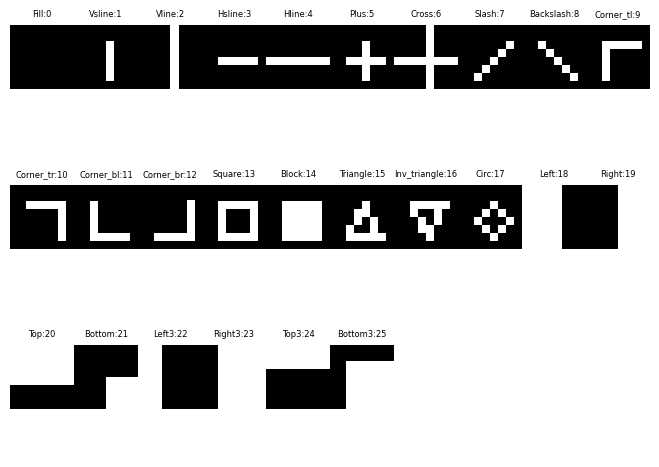

In [34]:
ds = xx, yy, labels, dd = glyph_dataset(len(Glyph), shape=(8,8), shuffle=False, txs=False)
print(xx.shape)
_=show_imgs(xx, ncols=10, title_size=6,  titles=[ f"{dd[i]['id']}:{dd[i]['label']}" for i in range(0, len(dd))])


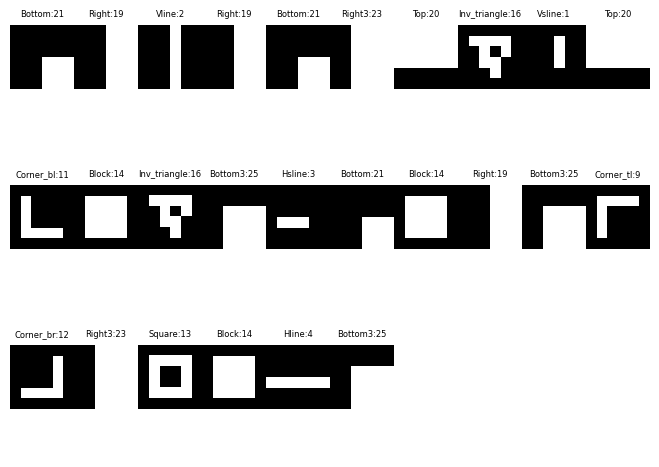

In [9]:
ds = xx, yy, labels, dd = glyph_dataset(40, shape=(6,6), txs=False)
_=show_imgs(xx, ncols=10, title_size=6,  titles=[ f"{dd[i]['id']}:{dd[i]['label']}" for i in range(0, len(dd))])


# Glyph Dataset classification

[0 1]
[<Glyph.SLASH: 8>, <Glyph.BACKSLASH: 9>]


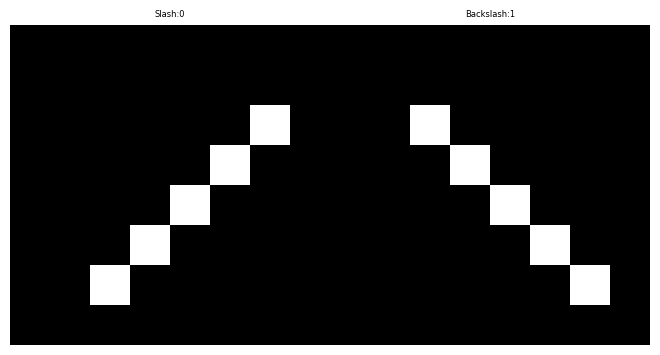

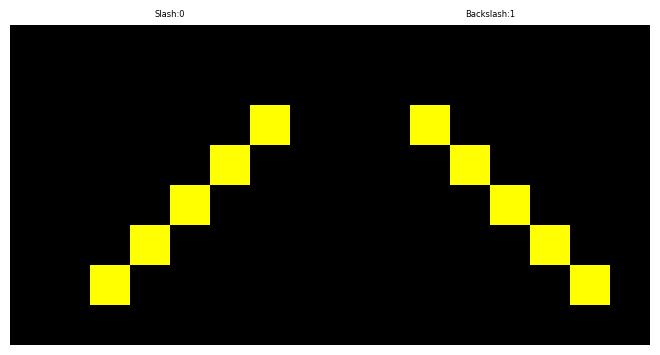

(2, 2)


,Slash,Backslash
Slash,0.078125,0.015625
Backslash,0.015625,0.078125


In [10]:
from spikeml.datasets.cv.glyph import Glyph, make_glyphs, show_glyphs, make_glyph, glyph_dataset, show_all_glyph_txs

gg = [Glyph.SQUARE, Glyph.CIRC, Glyph.SLASH, Glyph.BACKSLASH]
gg = [Glyph.SLASH, Glyph.BACKSLASH]
ds0 = xx, yy, labels, dd = glyph_dataset(len(gg), gg=gg, color=(255, 255, 0), unique=True, shuffle=False, shape=(8,8), txs=False)
ds_c = xx_c, yy_c, labels_c, dd_c = glyph_dataset(len(gg), gg=gg, color=(255, 255, 0), unique=True, shuffle=False, shape=(8,8,3), txs=False)

print(yy)
print(labels)

#xx = normalize_all(xx, 2)
#print(xx[0])
_=show_imgs(xx, ncols=min(10, xx.shape[0]), title_size=6,  titles=[ f"{dd[i]['id']}:{dd[i]['label']}" for i in range(0, len(dd))])
_=show_imgs(xx_c, ncols=min(10, xx.shape[0]), title_size=6,  titles=[ f"{dd_c[i]['id']}:{dd_c[i]['label']}" for i in range(0, len(dd_c))])

xx__ = xx.reshape(xx.shape[0], -1)
sim = (xx__ @ xx__.T)/xx__.shape[-1]
print(sim.shape)
#print(sim)
df = pd.DataFrame(sim, columns=gg, index=gg)
display(df)

#print(xx_c)

In [51]:
def show_kernels(M, shape, figsize=None):
    M = M.reshape(M.shape[0], shape[0], shape[1])
    show_imgs(M, ncols=min(M.shape[0],20), title_size=6,  figsize=figsize, titles=[f'{i}' for i in range(0, M.shape[0])])


def show_kernels_(M__, step=10, figsize=None):
    for t in range(0, len(M__)):
        if t % step != 0:
            continue
        show_imgs(M__[t], ncols=min(M.shape[0],20), title_size=6, figsize=figsize, titles=[f'{t}:{i}' for i in range(0, M__[0].shape[0])])
        #print(M__[t][0])

ll_2: 0/3: 0 : [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0.
  0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.
  0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]] -> [[0.0013 0.0013]
 [0.0014 0.0014]] [[0.0013 0.0013]
 [0.0014 0.0014]]
ll_2: 1/3: 1 : [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0.
  0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.
  0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]] -> [[0.0158 0.0158]
 [0.0167 0.0167]] [[0.0158 0.0158]
 [0.0167 0.0167]]
ll_2: 2/3: 2 : [[0. 0. 0. 0. 0. 0.

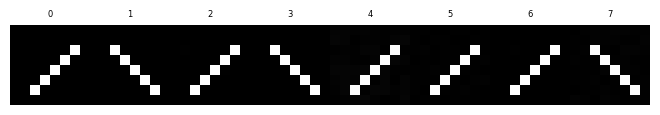

(2, 2)
Slash [0.1898 0.1898]
Backslash [0.1671 0.1671]


In [26]:

xx_ = xx.reshape(xx.shape[0], -1)
xx2 = np.repeat(xx, 20, axis=0)
xx2_ = xx2.reshape(xx2.shape[0], -1)

dataset = SimpleDataset(xx_)
loader = DataLoader(dataset, batch_size=10, shuffle=False, num_workers=0, pin_memory=False, seed=SEED)

def make_nn1(xx, labels):
    N = len(labels)*4
    nl_1 = NormalizeLayer(scale=3)
    M_1 = RateConnector((N, xx[0].size), params=ConnectorParams(mean=0, sd=.001, t_p=1,t_d=1, cmin=-10, cmax=10))
    M_2 = RateConnector((len(labels), N), params=ConnectorParams(mean=.1, sd=0, t_p=1, t_d=10, cmin=-10, cmax=10))
    ll_1 = LinearLayer(M_1, params=NNParams(), name='ll_1')
    ll_2 = LinearLayer(M_2, params=NNParams(), name='ll_2') 
    #print(M_1.params.fmt())
    #print(ll_1.params.fmt())
    nn = Chain([nl_1, ll_1, ll_2])
    return nn

yy__ = []
def _collect(source, x, y, context):
    print(f'll_2: {context.epoch}/{context.epochs}: {context.t} : {str(x)} -> {str(y)}', y)
    if context.epoch==context.epochs-1:
        yy__.append(y)
    
nn_1 = make_nn1(xx_, labels)

runner = DataRunner(nn_1, loader, epochs=3, plot=False, log_step=-1, log_epoch=-1, callback=_collect)
result = runner.run(options={'log.modules': False})
print(result)
show_kernels(nn_1['ll_1'].M.M, xx[0].shape)

yy__ = np.concatenate(yy__)
print(yy__.shape) 
for i in range(len(labels)):
    print(labels[i], yy__[i]) 
#print(ll1.M.M)



In [ ]:
yy_ = one_hot(yy, len(labels))
print(yy_)
print(labels)
dataset2_ = SimpleDataset(yy__, yy_)
loader2_ = DataLoader(dataset2_, batch_size=10, shuffle=False, num_workers=0, pin_memory=False, seed=SEED)

def make_nn2_(xx, labels):
    N = len(labels)*4
    M_2 = RateConnector((len(labels), N), params=ConnectorParams(mean=.1, sd=0, t_p=1, t_d=10, cmin=-10, cmax=10))
    ll_2 = LinearLayer(M_2, params=NNParams(), name='ll_2', force=True) 
    #print(M_1.params.fmt())
    #print(ll_1.params.fmt())
    nn = Chain([ll_2])
    return nn

nn2_ = make_nn2_(xx_, labels)


def _callback(_, x, y, context):
    print(ll_2.M.M)
    title = f'll_2: {context.epoch}/{context.epochs}: {context.t} {str(y)}'
    print(f'll_2: {context.epoch}/{context.epochs}: {context.t} : {str(x)} -> {str(y)}')
    show_img(ll_2.M.M, title=title)
        
runner_2_ = DataRunner(nn2_, loader2_, epochs=10, plot=False, log_step=-1, log_epoch=-1, callback=None) #_callback
result_2_ = runner_2.run(options={'log.modules': False})
print(result_2_)
show_img(nn2_['ll_2'], title='ll_2: final')


[[1 0]
 [0 1]]
[<Glyph.SLASH: 8>, <Glyph.BACKSLASH: 9>]
ConnectorParams:g=1,e_err=5,vmin=0,vmax=1,k_p=2,k_n=2,t_cp=10,t_cn=10,t_p=1.0,t_d=10.0,c_in=0,c_out=0,cmin=-10.0,cmax=10.0,mean=0,sd=0.1
NNParams:t_b=20,t_bn=30,e_b=2,g=1,e_err=5,vmin=0,vmax=1


NameError: name 'options' is not defined

[[1 0]
 [0 1]]
[<Glyph.SLASH: 8>, <Glyph.BACKSLASH: 9>]
{'ref': <spikeml.core.base.Chain object at 0x000001BB517CB430>, 'context': <spikeml.core.runner.Context object at 0x000001BB517C81C0>}


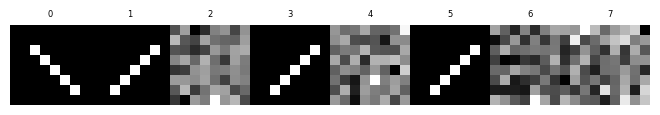

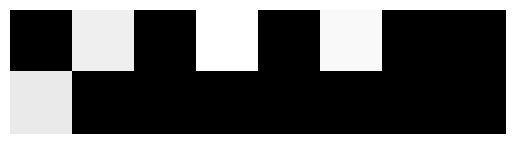

In [27]:
yy_ = one_hot(yy, len(labels))
print(yy_)
print(labels)

xx_ = xx.reshape(xx.shape[0], -1)
dataset_2 = SimpleDataset(xx_, yy_)

loader_2 = DataLoader(dataset_2, batch_size=-1, shuffle=False, num_workers=0, pin_memory=False, seed=SEED)

def make_nn(xx, labels):
    N = len(labels)*4
    nl_1 = NormalizeLayer(scale=3)
    M_1 = RateConnector((N, xx[0].size), params=ConnectorParams(mean=0, sd=.001, t_p=1, t_d=1, cmin=-10, cmax=10))
    M_2 = RateConnector((len(labels), N), params=ConnectorParams(mean=.1, sd=0, t_p=1, t_d=10, cmin=-10, cmax=10))
    ll_1 = LinearLayer(M_1, params=NNParams(), name='ll_1')
    ll_2 = LinearLayer(M_2, params=NNParams(), name='ll_2', force=True) 
    #print(M_1.params.fmt())
    #print(ll_1.params.fmt())
    nn = Chain([nl_1, ll_1, ll_2])
    return nn

nn_2 = make_nn(xx_, labels)

def _callback(_, x, y, context):
    print(f'll_2: {context.epoch}/{context.epochs}: {context.t} : {str(x)} -> {str(y)}')    
    ll_2.log()
    title = f'll_2: {context.epoch}/{context.epochs}: {context.t} {str(y)}'
    #show_kernels(ll_1.M.M, xx[0].shape)
    #show_img(ll_2.M.M, title=title)
    
runner_2 = DataRunner(nn_2, loader_2, epochs=10, plot=False, log_step=-1, log_epoch=-1, callback=None)#_callback)
result_2 = runner_2.run(options={'log.modules': False, 'log.connector': False})
print(result_2)
show_kernels(nn_2['ll_1'].M.M, xx[0].shape)
show_img(nn_2['ll_2'].M.M)
print(nn_2['ll_2'])


In [ ]:

yy_prob, yy_pred, metrics = eval(nn_2, xx_, yy, labels)
print(metrics)
print('yy_pred:', yy_pred)
for i in range(xx_.shape[0]):
    print(f'{i}: {labels[yy[i]]} ({yy[i]}) {yy_[i]} -> {yy_prob[i]} ({yy_pred[i]})')


{'accuracy': 1.0}
yy_pred: [0 1]
0: Slash (0) [1 0] -> [1. 0.] (0)
1: Backslash (1) [0 1] -> [0. 1.] (1)


## Glyph Dataset classification (4)

[0 1 2 3]
[<Glyph.SQUARE: 14>, <Glyph.CIRC: 18>, <Glyph.SLASH: 8>, <Glyph.BACKSLASH: 9>]


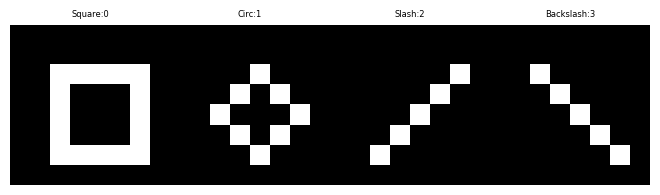

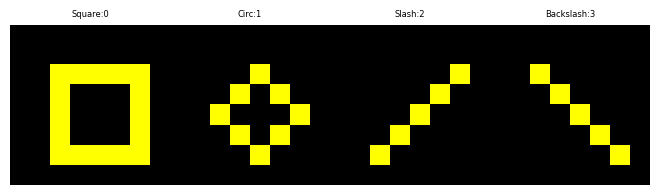

(4, 4)


,Square,Circ,Slash,Backslash
Square,0.25000,0.06250,0.031250,0.031250
Circ,0.06250,0.12500,0.031250,0.031250
Slash,0.03125,0.03125,0.078125,0.015625
Backslash,0.03125,0.03125,0.015625,0.078125


In [28]:
gg = [Glyph.SQUARE, Glyph.CIRC, Glyph.SLASH, Glyph.BACKSLASH]
glyphs4 = xx, yy, labels, dd = glyph_dataset(len(gg), gg=gg, color=(255, 255, 0), unique=True, shuffle=False, shape=(8,8), txs=False)
glyphs4c = xx_c, yy_c, labels_c, dd_c = glyph_dataset(len(gg), gg=gg, color=(255, 255, 0), unique=True, shuffle=False, shape=(8,8,3), txs=False)

print(yy)
print(labels)

#xx = normalize_all(xx, 2)
#print(xx[0])
_=show_imgs(xx, ncols=min(10, xx.shape[0]), title_size=6,  titles=[ f"{dd[i]['id']}:{dd[i]['label']}" for i in range(0, len(dd))])
_=show_imgs(xx_c, ncols=min(10, xx.shape[0]), title_size=6,  titles=[ f"{dd_c[i]['id']}:{dd_c[i]['label']}" for i in range(0, len(dd_c))])

xx__ = xx.reshape(xx.shape[0], -1)
sim = (xx__ @ xx__.T)/xx__.shape[-1]
print(sim.shape)
#print(sim)
df = pd.DataFrame(sim, columns=gg, index=gg)
display(df)

#print(xx_c)

[[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]
[<Glyph.SQUARE: 14>, <Glyph.CIRC: 18>, <Glyph.SLASH: 8>, <Glyph.BACKSLASH: 9>]
{'ref': <spikeml.core.base.Chain object at 0x000001BB4EAA7880>, 'context': <spikeml.core.runner.Context object at 0x000001BB4EAA5540>}


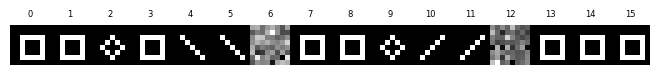

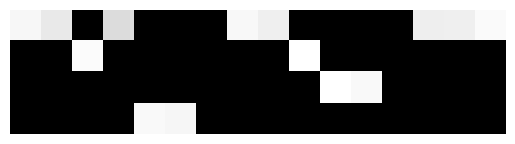

[[ 7.0105  6.5643 -0.9     6.1516 -0.8998 -0.9    -0.9     7.0378  6.7595 -0.9    -0.8982 -0.9    -0.9     6.7112
   6.7665  7.0927]
 [-0.9    -0.9     7.1339 -0.9    -0.9    -0.9    -0.9    -0.9    -0.9     7.2789 -0.9    -0.8925 -0.9    -0.9
  -0.9    -0.9   ]
 [-0.9    -0.9    -0.9    -0.9    -0.9    -0.9    -0.9    -0.9    -0.9    -0.9     7.2656  7.0712 -0.9    -0.9
  -0.9    -0.9   ]
 [-0.9    -0.9    -0.8998 -0.9     7.0767  6.9874 -0.9    -0.9    -0.9    -0.9    -0.9    -0.9    -0.9    -0.9
  -0.9    -0.9   ]]


In [30]:
yy_ = one_hot(yy, len(labels))
print(yy_)
print(labels)

xx_ = xx.reshape(xx.shape[0], -1)
dataset_2 = SimpleDataset(xx_, yy_)
loader_2 = DataLoader(dataset_2, batch_size=-1, shuffle=False, num_workers=0, pin_memory=False, seed=SEED)

def make_nn(xx, labels):
    N = len(labels)*4
    nl_1 = NormalizeLayer(scale=3)
    M_1 = RateConnector((N, xx[0].size), params=ConnectorParams(mean=0, sd=.001, t_p=1, t_d=1, cmin=-10, cmax=10))
    M_2 = RateConnector((len(labels), N), params=ConnectorParams(mean=.1, sd=0, t_p=1, t_d=10, cmin=-10, cmax=10))
    ll_1 = LinearLayer(M_1, params=NNParams(), name='ll_1')
    ll_2 = LinearLayer(M_2, params=NNParams(), name='ll_2', force=True) 
    #print(M_1.params.fmt())
    #print(ll_1.params.fmt())
    nn = Chain([nl_1, ll_1, ll_2])
    return nn

nn_2 = make_nn(xx_, labels)

def _callback(_, x, y, context):
    print(f'll_2: {context.epoch}/{context.epochs}: {context.t} : {str(x)} -> {str(y)}')    
    ll_2.log()
    title = f'll_2: {context.epoch}/{context.epochs}: {context.t} {str(y)}'
    #show_kernels(ll_1.M.M, xx[0].shape)
    #show_img(ll_2.M.M, title=title)
    
runner_2 = DataRunner(nn_2, loader_2, epochs=10, plot=False, log_step=-1, log_epoch=-1, callback=None)#_callback)
result_2 = runner_2.run(options={'log.modules': False, 'log.connector': False})
print(result_2)
show_kernels(nn_2['ll_1'].M.M, xx[0].shape)
show_img(nn_2['ll_2'].M.M)
print(nn_2['ll_2'].M.M)


In [31]:
yy_prob, yy_pred, metrics = eval(nn_2, xx_, yy, labels)
print(metrics)
print('yy_pred:', yy_pred)
for i in range(xx_.shape[0]):
    print(f'{i}: {labels[yy[i]]} ({yy[i]}) {yy_[i]} -> {yy_prob[i]} ({yy_pred[i]})')


{'accuracy': 1.0}
yy_pred: [0 1 2 3]
0: Square (0) [1 0 0 0] -> [1. 0. 0. 0.] (0)
1: Circ (1) [0 1 0 0] -> [0. 1. 0. 0.] (1)
2: Slash (2) [0 0 1 0] -> [0. 0. 1. 0.] (2)
3: Backslash (3) [0 0 0 1] -> [0. 0. 0. 1.] (3)


## Glyph Dataset classification (N)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
[<Glyph.VSLINE: 2>, <Glyph.VLINE: 3>, <Glyph.HSLINE: 4>, <Glyph.HLINE: 5>, <Glyph.PLUS: 6>, <Glyph.CROSS: 7>, <Glyph.SLASH: 8>, <Glyph.BACKSLASH: 9>, <Glyph.CORNER_TL: 10>, <Glyph.CORNER_TR: 11>, <Glyph.CORNER_BL: 12>, <Glyph.CORNER_BR: 13>, <Glyph.SQUARE: 14>, <Glyph.BLOCK: 15>, <Glyph.TRIANGLE: 16>, <Glyph.INV_TRIANGLE: 17>, <Glyph.CIRC: 18>]


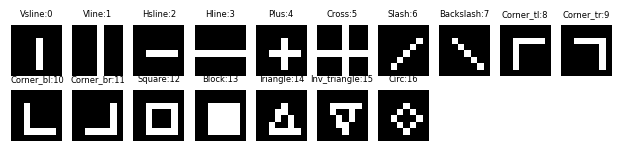

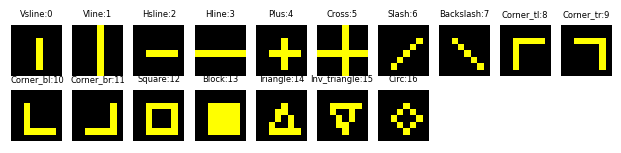

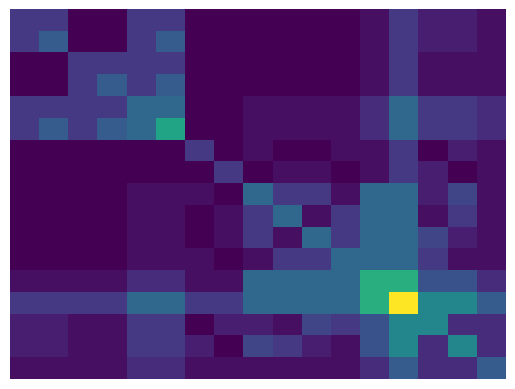

(17, 17)


,Vsline,Vline,Hsline,Hline,Plus,Cross,Slash,Backslash,Corner_tl,Corner_tr,Corner_bl,Corner_br,Square,Block,Triangle,Inv_triangle,Circ
Vsline,0.078125,0.078125,0.015625,0.015625,0.078125,0.078125,0.015625,0.015625,0.015625,0.015625,0.015625,0.015625,0.031250,0.078125,0.046875,0.046875,0.03125
Vline,0.078125,0.125000,0.015625,0.015625,0.078125,0.125000,0.015625,0.015625,0.015625,0.015625,0.015625,0.015625,0.031250,0.078125,0.046875,0.046875,0.03125
Hsline,0.015625,0.015625,0.078125,0.078125,0.078125,0.078125,0.015625,0.015625,0.015625,0.015625,0.015625,0.015625,0.031250,0.078125,0.031250,0.031250,0.03125
Hline,0.015625,0.015625,0.078125,0.125000,0.078125,0.125000,0.015625,0.015625,0.015625,0.015625,0.015625,0.015625,0.031250,0.078125,0.031250,0.031250,0.03125
Plus,0.078125,0.078125,0.078125,0.078125,0.140625,0.140625,0.015625,0.015625,0.031250,0.031250,0.031250,0.031250,0.062500,0.140625,0.078125,0.078125,0.06250
Cross,0.078125,0.125000,0.078125,0.125000,0.140625,0.234375,0.015625,0.015625,0.031250,0.031250,0.031250,0.031250,0.062500,0.140625,0.078125,0.078125,0.06250
Slash,0.015625,0.015625,0.015625,0.015625,0.015625,0.015625,0.078125,0.015625,0.031250,0.015625,0.015625,0.031250,0.031250,0.078125,0.015625,0.046875,0.03125
Backslash,0.015625,0.015625,0.015625,0.015625,0.015625,0.015625,0.015625,0.078125,0.015625,0.031250,0.031250,0.015625,0.031250,0.078125,0.046875,0.015625,0.03125
Corner_tl,0.015625,0.015625,0.015625,0.015625,0.031250,0.031250,0.031250,0.015625,0.140625,0.078125,0.078125,0.031250,0.140625,0.140625,0.046875,0.093750,0.03125
Corner_tr,0.015625,0.015625,0.015625,0.015625,0.031250,0.031250,0.015625,0.031250,0.078125,0.140625,0.031250,0.078125,0.140625,0.140625,0.031250,0.078125,0.03125


In [58]:
gg = [#Glyph.FILL, 
    Glyph.VSLINE, Glyph.VLINE, Glyph.HSLINE, Glyph.HLINE, Glyph.PLUS, Glyph.CROSS, Glyph.SLASH, Glyph.BACKSLASH,
    Glyph.CORNER_TL, Glyph.CORNER_TR, Glyph.CORNER_BL, Glyph.CORNER_BR, Glyph.SQUARE,
    Glyph.BLOCK, Glyph.TRIANGLE, Glyph.INV_TRIANGLE, Glyph.CIRC,
    #Glyph.LEFT, Glyph.RIGHT, Glyph.TOP, Glyph.BOTTOM,   
    #Glyph.LEFT3, Glyph.RIGHT3, Glyph.TOP3, Glyph.BOTTOM3
    ] 
    
glyphsN = xx, yy, labels, dd = glyph_dataset(len(gg), gg=gg, color=(255, 255, 0), unique=True, shuffle=False, shape=(8,8), txs=False)
glyphsNc = xx_c, yy_c, labels_c, dd_c = glyph_dataset(len(gg), gg=gg, color=(255, 255, 0), unique=True, shuffle=False, shape=(8,8,3), txs=False)

print(yy)
print(labels)

#xx = normalize_all(xx, 2)
#print(xx[0])
_=show_imgs(xx, ncols=min(10, xx.shape[0]), figsize=(10,2), pad=.2, title_size=6,  titles=[ f"{dd[i]['id']}:{dd[i]['label']}" for i in range(0, len(dd))])
_=show_imgs(xx_c, ncols=min(10, xx.shape[0]), figsize=(10,2),  pad=.2, title_size=6,  titles=[ f"{dd_c[i]['id']}:{dd_c[i]['label']}" for i in range(0, len(dd_c))])


xx__ = xx.reshape(xx.shape[0], -1)
sim = (xx__ @ xx__.T)/xx__.shape[-1]
mshow(sim)
print(sim.shape)
#print(sim)
df = pd.DataFrame(sim, columns=gg, index=gg)
display(df)

#print(xx_c) 

[<Glyph.VSLINE: 2>, <Glyph.VLINE: 3>, <Glyph.HSLINE: 4>, <Glyph.HLINE: 5>, <Glyph.PLUS: 6>, <Glyph.CROSS: 7>, <Glyph.SLASH: 8>, <Glyph.BACKSLASH: 9>, <Glyph.CORNER_TL: 10>, <Glyph.CORNER_TR: 11>, <Glyph.CORNER_BL: 12>, <Glyph.CORNER_BR: 13>, <Glyph.SQUARE: 14>, <Glyph.BLOCK: 15>, <Glyph.TRIANGLE: 16>, <Glyph.INV_TRIANGLE: 17>, <Glyph.CIRC: 18>]


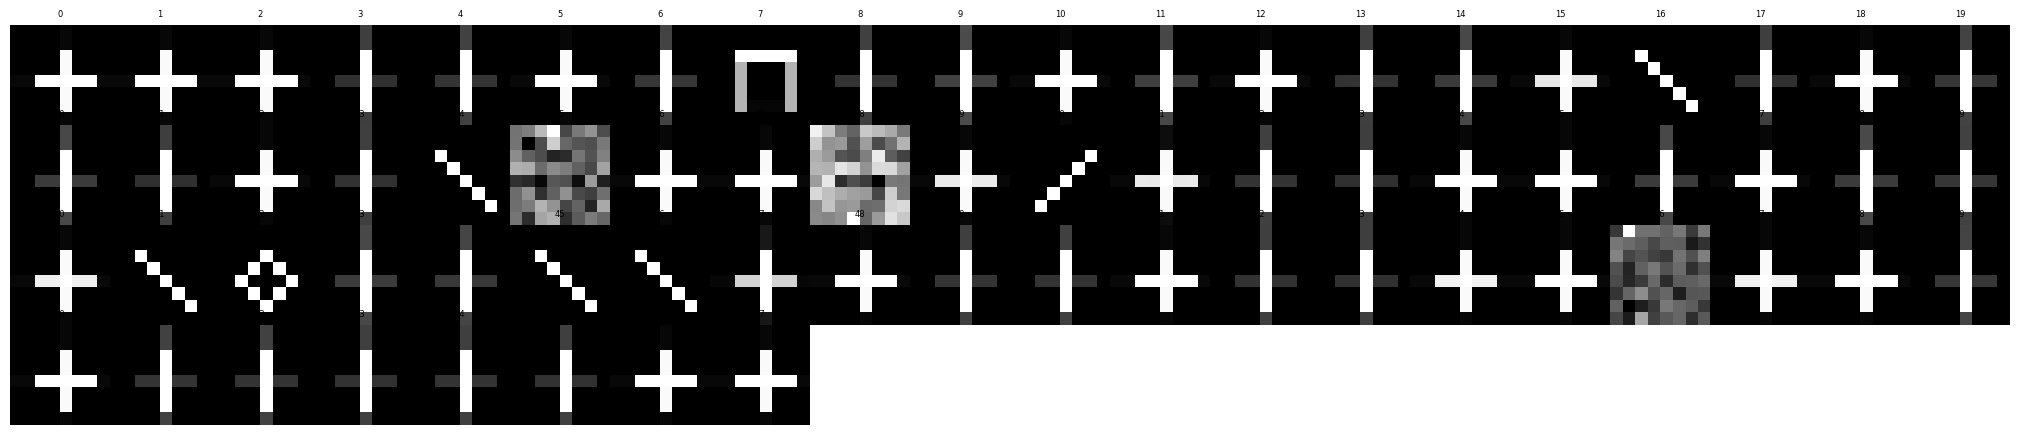

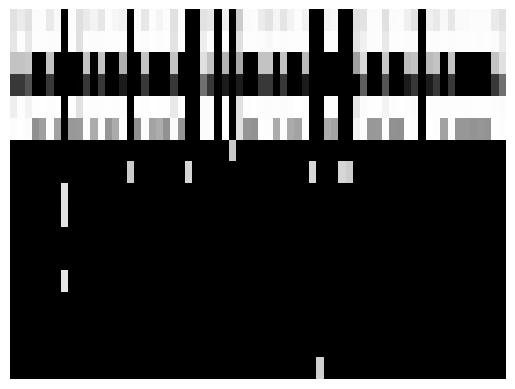

<Axes: >

In [59]:
yy_ = one_hot(yy, len(labels))
#print(yy_)
print(labels)

xx_ = xx.reshape(xx.shape[0], -1)
dataset_2 = SimpleDataset(xx_, yy_)
loader_2 = DataLoader(dataset_2, batch_size=-1, shuffle=False, num_workers=0, pin_memory=False, seed=SEED)

def make_nn(xx, labels):
    N = len(labels)*4
    nl_1 = NormalizeLayer(scale=3)
    M_1 = RateConnector((N, xx[0].size), params=ConnectorParams(mean=0, sd=.001, t_p=1, t_d=1, cmin=-10, cmax=10))
    M_2 = RateConnector((len(labels), N), params=ConnectorParams(mean=.1, sd=0, t_p=1, t_d=10, cmin=-10, cmax=10))
    ll_1 = LinearLayer(M_1, params=NNParams(), name='ll_1')
    ll_2 = LinearLayer(M_2, params=NNParams(), name='ll_2', force=True) 
    #print(M_1.params.fmt())
    #print(ll_1.params.fmt())
    nn = Chain([nl_1, ll_1, ll_2])
    return nn

nn_2 = make_nn(xx_, labels)

def _callback(_, x, y, context):
    print(f'll_2: {context.epoch}/{context.epochs}: {context.t} : {str(x)} -> {str(y)}')    
    ll_2.log()
    title = f'll_2: {context.epoch}/{context.epochs}: {context.t} {str(y)}'
    #show_kernels(ll_1.M.M, xx[0].shape)
    #show_img(ll_2.M.M, title=title)
    
runner_2 = DataRunner(nn_2, loader_2, epochs=10, plot=False, log_step=-1, log_epoch=-1, callback=None)#_callback)
result_2 = runner_2.run(options={'log.modules': False, 'log.connector': False})
#print(result_2)
show_kernels(nn_2['ll_1'].M.M, xx[0].shape, figsize=(20, 4))
show_img(nn_2['ll_2'].M.M)
#print(nn_2['ll_2'].M.M)


{'accuracy': 0.29411764705882354, 'confusion_matrix': array([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

,Vsline,Vline,Hsline,Hline,Plus,Cross,Slash,Backslash,Corner_tl,Corner_tr,Corner_bl,Corner_br,Square,Block,Triangle,Inv_triangle,Circ
Vsline,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Vline,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Hsline,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Hline,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Plus,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Cross,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Slash,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
Backslash,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
Corner_tl,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
Corner_tr,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0


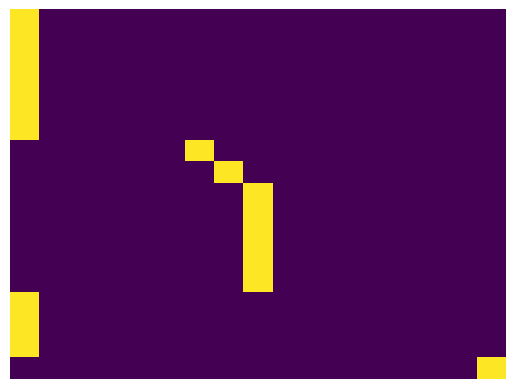

0: Vsline (0) -> Vsline (0) [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0] -> [1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
1: Vline (1) -> Vsline (0) [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0] -> [1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
2: Hsline (2) -> Vsline (0) [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0] -> [1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
3: Hline (3) -> Vsline (0) [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0] -> [1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
4: Plus (4) -> Vsline (0) [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0] -> [1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
5: Cross (5) -> Vsline (0) [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0] -> [1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
6: Slash (6) -> Slash (6) [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0] -> [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
7: Backslash (7) -> Backslash (7) [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0] -> [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
8: Corner_tl (8) -> Corner_tl (8) [0 0 0 

In [ ]:
yy_prob, yy_pred, metrics = eval(nn_2, xx_, yy, labels)
print(metrics)
print('yy_pred:', yy_pred)
cm_norm = metrics['confusion_matrix'] / metrics['confusion_matrix'].sum(axis=1, keepdims=True)

cm = pd.DataFrame(metrics['confusion_matrix'], index=labels, columns=labels)
display(cm)
mshow(cm)

print_pred(xx_, yy, yy_pred, labels, details=True)


# Digits Dataset classification (10)

(1797, 64)


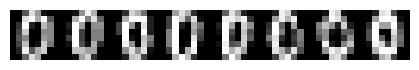

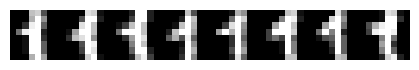

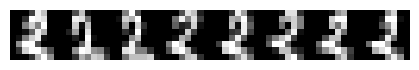

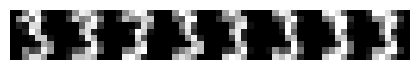

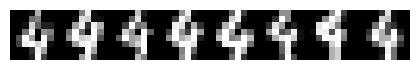

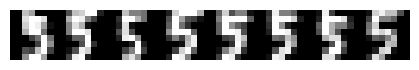

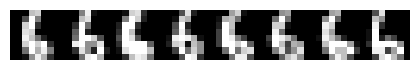

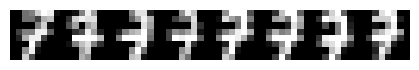

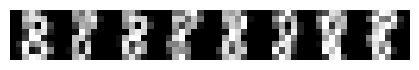

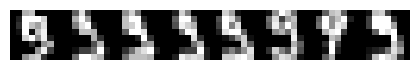

In [70]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import numpy as np

digits = load_digits()

print(digits.data.shape)
X = digits.images   # shape: (1797, 8, 8)
y = digits.target   # shape: (1797,)

def show_img_dataset(X, y, labels=None, nsamples=6, ncols=None, figsize=None):
    y_ = np.unique(y).tolist()
    if ncols is None:
        ncols = nsamples
    if figsize is None:
        figsize=(ncols, 1)
    for label in y_:
        ii = np.where(y == label)[0]
        if ii.shape[0]==0:
            continue
        ii = ii[:min(ii.shape[0], nsamples)]
        stitle = f'{labels[label]} ({label})' if labels is not None else  f'{label}'
        show_imgs(X[ii], ncols=nsamples, suptitle=stitle, title_size=8, figsize=figsize)

show_img_dataset(X, y, nsamples=8, figsize=(8*.5, .5))

epoch = 0:
epoch = 1:
epoch = 2:
epoch = 3:
epoch = 4:
epoch = 5:
epoch = 6:
epoch = 7:
epoch = 8:
epoch = 9:


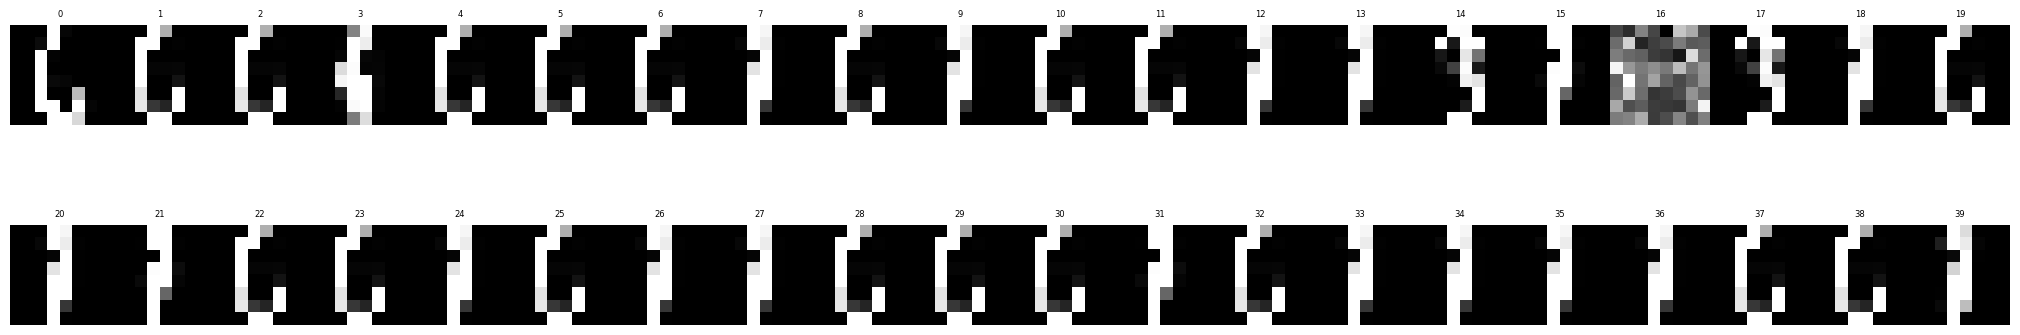

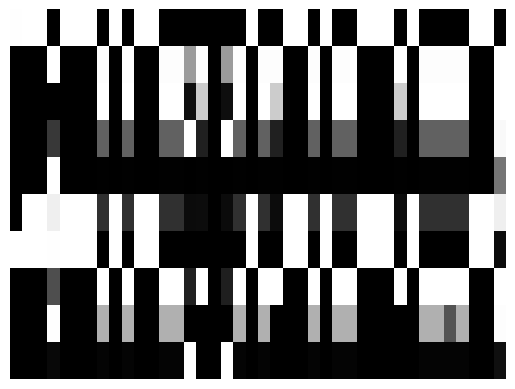

<Axes: >

In [80]:
yy = digits.target
yy_ = one_hot(yy, 10)
xx_ = digits.data
dataset_2 = SimpleDataset(xx_, yy_)
loader_2 = DataLoader(dataset_2, batch_size=-1, shuffle=False, num_workers=0, pin_memory=False, seed=SEED)

def make_nn(xx, nclasses):
    N = nclasses*4
    nl_1 = NormalizeLayer(scale=3)
    M_1 = RateConnector((N, xx[0].size), params=ConnectorParams(mean=0, sd=.001, t_p=1, t_d=1, cmin=-10, cmax=10))
    M_2 = RateConnector((nclasses, N), params=ConnectorParams(mean=.1, sd=0, t_p=1, t_d=10, cmin=-10, cmax=10))
    ll_1 = LinearLayer(M_1, params=NNParams(), name='ll_1')
    ll_2 = LinearLayer(M_2, params=NNParams(), name='ll_2', force=True) 
    #print(M_1.params.fmt())
    #print(ll_1.params.fmt())
    nn = Chain([nl_1, ll_1, ll_2])
    return nn

nn_2 = make_nn(xx_, 10)
    
runner_2 = DataRunner(nn_2, loader_2, epochs=10, plot=False, log_step=-1, log_epoch=1, callback=None)#_callback)
result_2 = runner_2.run(options={'log.modules': False, 'log.connector': False})
#print(result_2)
show_kernels(nn_2['ll_1'].M.M, xx[0].shape, figsize=(20, 4))
show_img(nn_2['ll_2'].M.M)
#print(nn_2['ll_2'].M.M)


In [82]:
from  spikeml.core.metrics import eval, print_pred


In [ ]:
yy_prob, yy_pred, metrics = eval(nn_2, xx_, yy)
print(metrics)
print('yy_pred:', yy_pred)
#cm_norm = metrics['confusion_matrix'] / metrics['confusion_matrix'].sum(axis=1, keepdims=True)

cm = pd.DataFrame(metrics['confusion_matrix'], index=labels, columns=labels)
display(cm)
mshow(cm)

print_pred(xx_, yy, yy_pred, yy_prob)


{'accuracy': 0.27378964941569284, 'confusion_matrix': array([[177,   1,   0,   0,   0,   0,   0,   0,   0,   0],
       [ 41, 137,   0,   4,   0,   0,   0,   0,   0,   0],
       [ 97,  72,   3,   5,   0,   0,   0,   0,   0,   0],
       [ 11,  23,   0, 149,   0,   0,   0,   0,   0,   0],
       [ 37, 142,   0,   0,   2,   0,   0,   0,   0,   0],
       [114,  62,   0,   6,   0,   0,   0,   0,   0,   0],
       [107,  49,   0,   0,   1,   0,  24,   0,   0,   0],
       [ 85,  93,   0,   1,   0,   0,   0,   0,   0,   0],
       [ 92,  54,   0,  26,   2,   0,   0,   0,   0,   0],
       [ 95,   6,   0,  79,   0,   0,   0,   0,   0,   0]])}
yy_pred: [0 1 0 ... 1 3 0]



KeyboardInterrupt



In [ ]:
def tiles(a, K, S):
    tiles = sliding_window_view(a, (K, K))
    return tiles[::S, ::S]

print(X_.shape)

Xs=tiles(X_[0], K=9, S=9)
print(Xs.shape)

Xs_ = Xs.reshape(-1, *Xs.shape[2:])
Xs__ = Xs_.reshape(Xs_.shape[0], -1)
print(Xs.shape, Xs_.shape, Xs__.shape)
show_imgs(Xs_, titles=None, ncols=Xs.shape[0], nrows=Xs.shape[1], title_size=6, figsize=(5,5), pad=.01)



# MNIST Dataset classification (10)

(70000, 784) (70000,)
(70000, 28, 28) (70000,)


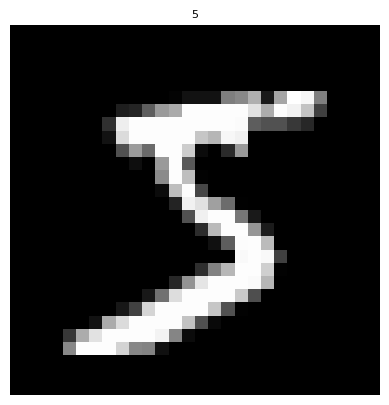

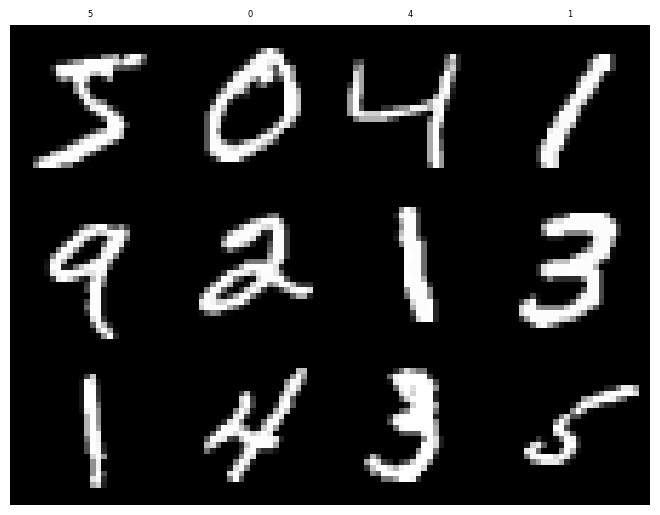

array([<Axes: title={'center': '5'}>, <Axes: title={'center': '0'}>, <Axes: title={'center': '4'}>,
       <Axes: title={'center': '1'}>, <Axes: title={'center': '9'}>, <Axes: title={'center': '2'}>,
       <Axes: title={'center': '1'}>, <Axes: title={'center': '3'}>, <Axes: title={'center': '1'}>,
       <Axes: title={'center': '4'}>, <Axes: title={'center': '3'}>, <Axes: title={'center': '5'}>], dtype=object)

In [33]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data        # shape (70000, 784)
y = mnist.target     # labels as strings
print(X.shape, y.shape)
y_ = y.astype(int) # Convert labels to int
X_ = X.reshape(-1, 28, 28)
print(X_.shape, y.shape)
show_img(X_[0], title=f'{y[0]}', cmap=None, bgr=False, title_size=8, figsize=None)
show_imgs(X_[:12], titles=y[:12].tolist(), ncols=4, nrows=None, title_size=6, figsize=None, pad=0)



In [32]:
def predictors(M, xx, yy, labels, pp=None, jj=None, debug=False):
    eps = 0.00001
    if pp is None:
        pp = [.1*k for k in range(1,10)]
    ny = len(labels)
    cm = np.zeros((ny, len(pp), M.shape[0], 2, 2), dtype=int)
    ce = np.zeros((ny, M.shape[0]), dtype=float)
    if jj is None:
        jj = range(0, M.shape[0])
    predictors_ = np.array((ny,len(pp), M.shape[0]), dtype=bool)
    zy = propagate_batch(M, xx)
    zy_ = np.clip(zy, eps, 1-eps)
    Zy = np.zeros((ny, M.shape[0]), dtype=float)
    np.add.at(Zy, yy, zy)
    counts = np.bincount(yy, minlength=ny)
    Zy = np.divide(Zy, counts[:, None],
        out=np.zeros_like(Zy, dtype=float),
        where=counts[:, None] > 0
    )
    print(Zy)
    for i in range(0, zy.shape[0]):
        lb = yy[i]
        y = zy[i]
        if debug:
            print(f'{i}:', 'target:', lb, labels[lb], 'y:', y, ':') 

        for k in range(0, len(pp)):
            p = pp[k]
            #np.where(yy[i] > p)[0]
            for j in jj:
                yj = y[j]
                pred = yj>=p
                if pred:
                    for lb_ in range(0, ny):
                        if lb_==lb:
                            cm[lb,k,j,0,0] += 1 #TP 
                            #if debug:
                            #    print('  TP:', 'j:', j, 'yj:', yj, 'p:', p, 'pred:', lb_, labels[lb_], 'cm:', cm[lb,k,j].tolist())
                        else:
                            cm[lb_,k,j,1,0] += 1  #FP 
                            #if debug:
                            #    print('  FP:', 'j:', j, 'yj:', yj, 'p:', p, 'pred:', lb_, labels[lb_], 'cm:', cm[lb_,k,j].tolist())
                else:
                    for lb_ in range(0, ny):
                        if lb_==lb:
                            cm[lb,k,j,0,1] += 1  #FN
                            #if debug:
                            #    print('  FN:', 'j:', j, 'yj:', yj, 'p:', p, 'pred:', lb_, labels[lb_], 'cm:', cm[lb,k,j].tolist())
                        else:
                            cm[lb_,k,j,1,1] += 1  #TN                            
                            #if debug:
                            #    print('  TN:', 'j:', j, 'yj:', yj, 'p:', p, 'pred:', lb_, labels[lb_], 'cm:', cm[lb_,k,j].tolist())
        for j in jj:
            y_ = zy_[i]
            for lb_ in range(0, ny):
                if lb_==lb:
                    ce[lb_,j] -= math.log(y_[j])
                else:
                    ce[lb_,j] -= math.log(1-y_[j])
    ce /= xx.shape[0]
    acc = np.zeros((ny, len(pp), M.shape[0]), dtype=float)
    prec = np.zeros((ny, len(pp), M.shape[0]),  dtype=float)
    recal = np.zeros((ny, len(pp), M.shape[0]), dtype=float)
    for i in range(0, ny):
        lb = yy[i]
        #if debug:
        #    print( f'{i}:', 'target:',  lb, labels[lb]) 
        for k in range(0, len(pp)):
        #    if debug:
        #        print( f'  {k}: p:', pp[k]) 
            for j in jj:
                acc[lb,k,j] = float(cm[lb,k,j,0,0] + cm[lb,k,j,1,1])/xx_.shape[0]
                n = cm[lb,k,j,0,0] + cm[lb,k,j,1,0]
                prec[lb,k,j] = float(cm[lb,k,j,0,0])/n if n>0 else 0
                n = cm[lb,k,j,0,0] + cm[lb,k,j,0,1]
                recal[lb,k,j] = float(cm[lb,k,j,0,0])/n if n>0 else 0
        #        if debug:
        #            print('    j:', j, 'acc:', acc[lb, k, j],  'prec:', prec[lb, k, j], 'recal:', recal[lb, k, j])

    predictor_pacc = np.argmax(acc, -1)  
    predictor_pprec = np.argmax(prec, -1)  
    predictor_precal = np.argmax(recal, -1)  
    best_pacc = np.max(acc, -1)
    best_pprec = np.max(prec, -1)
    best_precal = np.max(recal, -1)
    
    K = 3
    iacc = np.argsort(acc, -1)[-K:]

    best_acc = np.max(best_pacc, 1)
    best_acc_p = np.argmax(best_pacc, 1)
    L = np.arange(ny)
    predictor_acc = predictor_pacc[L,best_acc_p]
    print(predictor_pacc.shape, best_acc_p.shape, predictor_acc.shape)
    
    best_prec = np.max(best_pprec, 1)
    best_prec_p = np.argmax(best_pprec, 1)
    predictor_prec = predictor_pprec[L,best_prec_p]

    best_recal = np.max(best_precal, 1)
    best_recal_p = np.argmax(best_precal, 1)
    predictor_recal = predictor_precal[L,best_recal_p]

    predictor_ce = np.argmin(ce, 1)
    best_ce = np.min(ce, 1) 


    return {'ny': ny, 'cm': cm, 'pp': pp, 'acc': acc, 'prec': prec, 'recal': recal,
            'predictor_pacc': predictor_pacc, 'predictor_pprec': predictor_pprec, 'predictor_precal': predictor_precal,
            'predictor_acc': predictor_acc, 'predictor_prec': predictor_prec, 'predictor_recal': predictor_recal,
            'best_acc': best_acc, 'best_prec': best_prec, 'best_recal': best_recal,
            'best_pacc': best_pacc, 'best_pprec': best_pprec, 'best_precal': best_precal,
            'best_acc_p': best_acc_p, 'best_prec_p': best_prec_p, 'best_recal_p': best_recal_p,
            'ce': ce, 'predictor_ce': predictor_ce, 'best_ce': best_ce}


xx_ = normalize_all(xx, 2)*3

print(xx.shape, xx_.shape)
for i in range(0, xx_.shape[0]):
    y = propagate(M, xx_[i])
    print(f'{i}:', dd[i]['id'], yy[i], y)

print(yy)
print(labels)
metrics = predictors(M, xx_, yy, labels, pp=[.5], debug=True)

for j in range(0, M.shape[0]):
    print('cm:', j, metrics['cm'][:,0,j].tolist())
#print(metrics['ce'])
print('predictor_acc:', metrics['predictor_acc'].tolist())
for i in range(0, metrics['best_acc'].shape[0]):
    print(labels[i], '; predictor_acc:', metrics['predictor_acc'][i].tolist(), '; best_acc:', metrics['best_acc'][i].tolist())
for i in range(0, metrics['ce'].shape[0]):
    print(labels[i], 'ce:', metrics['ce'][i])
for i in range(0, metrics['ce'].shape[0]):
    print(labels[i], 'predictor_ce:', metrics['predictor_ce'][i], 'best_ce:', metrics['best_ce'][i])
#print(nn.shape)
#print(nn)

predictors = metrics['predictor_acc']
print(predictors)
kernels = [M[i].reshape(xx[0].shape) for i in range(0, predictors.shape[0]) ]
show_imgs(kernels, ncols=min(len(Y), 10), title_size=6, titles=gg)


(4, 8, 8) (4, 8, 8)


d:\git\rd\dynaspike\nb\tests\spikeml\cv\../../../../src\spikeml\utils\vector.py:242: RuntimeWarning: invalid value encountered in divide
  a = a / n[:,None]


NameError: name 'propagate' is not defined

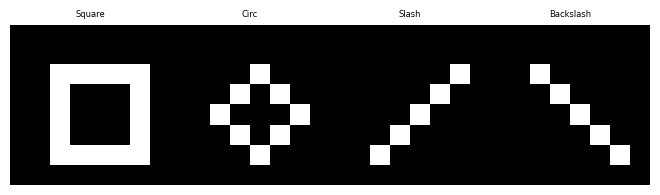

{'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'precision_per_class': array([1., 1., 1., 1.]), 'recall_per_class': array([1., 1., 1., 1.]), 'cm': array([[1, 0, 0, 0],
       [0, 1, 0, 0],
       [0, 0, 1, 0],
       [0, 0, 0, 1]])}


In [ ]:
def predict(xx, M, metrics, d2=True, predictor='acc'):
    yy = propagate_batch(M, xx, d2=True)
    pred = None
    if predictor=='acc':
        predictor = metrics['predictor_acc']
        p = metrics['best_acc_p']
        #print(predictor)
        #print(yy)
        ny = metrics['ny']
        pred_ = yy[:, predictor]
        pred = np.argmax(pred_, 1)
        #print(pred_)
        #print(pred)
    elif predictor=='ce':
        predictor = metrics['predictor_ce']
    else:
        return None
    return pred

    
def eval(xx, yy, M, metrics, d2=True, predictor='acc'):
    n = 0
    pred = predict(xx, M, metrics, d2, predictor) 
    acc = (pred==yy).mean()
    C = metrics['ny']
    precision_per_class = np.zeros(C)
    recall_per_class = np.zeros(C)
    cm = np.zeros((C, C), dtype=int)
    np.add.at(cm, (yy, pred), 1)
    for i, c in enumerate(range(C)):
        tp = np.sum((pred == c) & (yy == c))
        fp = np.sum((pred == c) & (yy != c))
        fn = np.sum((pred != c) & (yy == c))
        tn = np.sum((pred != c) & (yy != c))
        precision_per_class[i] = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall_per_class[i]    = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    precision = precision_per_class.mean()
    recall    = recall_per_class.mean()
    metrics = {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'precision_per_class': precision_per_class,
        'recall_per_class': recall_per_class,
        'cm': cm
    }
    return metrics

pred = predict(xx_, M, metrics)
show_imgs(xx_, ncols=min(pred.shape[0], 10), title_size=6, titles=[gg[pred[i]] for i in range(pred.shape[0])])

metrics_ = eval(xx_, yy, M, metrics)
print(metrics_)

(2, 28, 28)
pca.explained_variance_ratio_: [1.00000000e+00 1.52179488e-31]
pca.singular_values_: [1.53000000e+03 5.96855898e-13]
pca.components_ [[ 3.90101894e-16 -0.00000000e+00 -0.00000000e+00 ... -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00]
 [ 1.00000000e+00 -0.00000000e+00 -0.00000000e+00 ... -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00]]


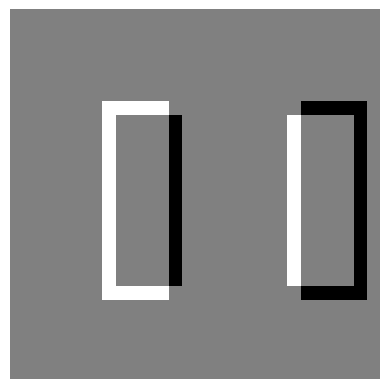

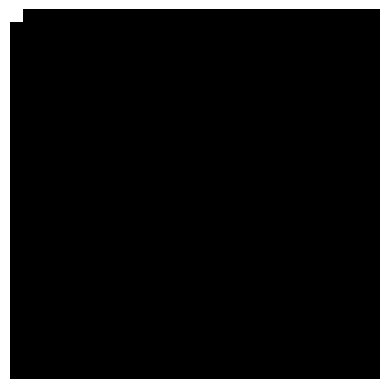

In [ ]:
from sklearn.decomposition import PCA

ds = np.array([a, a1]) #, ra
print(ds.shape)
pca = PCA(n_components=2)
pca.fit(ds.reshape(ds.shape[0], -1))

print('pca.explained_variance_ratio_:', pca.explained_variance_ratio_)
print('pca.singular_values_:', pca.singular_values_)
print('pca.components_', pca.components_)
for i in range(0, pca.components_.shape[0]):
    eimg = pca.components_[i].reshape(a.shape)
    show_img(eimg)


In [ ]:
A=Xs__
A_ = A[:, :, None] * A[:, None, :]
print(A.shape, Xs__.shape)

show_imgs(A_, titles=None, ncols=A_.shape[0], nrows=Xs.shape[1], title_size=6, figsize=(5,5), pad=.01)
